# ADS1001 Project — Member 2 Final Notebook  
## Dataset Overview, Data Cleaning, Data Quality Checks and Analysis-Ready Dataset

**Project theme:** Which weather indicators are most useful for public weather communication in Malaysia?  
**Member 2 responsibility:** Dataset overview, data dictionary alignment, data cleaning, quality checks, feature preparation, and limitations for later analysis.

This notebook is designed to support the group presentation, poster and final report notebook. It documents the dataset structure, cleaning decisions and data quality limitations before the other members conduct comfort and warning-indicator analysis.

### Group Member
- **CHEN ZIMO**



## 1. Title, Members & Theme

**Client:** A Malaysian public weather information service that provides weather guidance to residents, commuters and outdoor users.

**Client problem:** The client has access to many weather variables, but not every raw measurement is equally easy for the public to understand or act on.

**Main project question:**  
Which weather indicators are most useful for communicating outdoor comfort, rainfall conditions, wind-related risk and UV exposure to the Malaysian public?

**Member 2 contribution:**  
This section prepares a reliable analysis-ready dataset by checking missing values, duplicate rows, location coverage, unusual values, datetime fields and imputation impact.

## 2. Data Dictionary Summary

The weather data dictionary describes the following key variables:

| Variable | Meaning | Unit / Type | Later project use |
|---|---|---|---|
| `temperature` | Air temperature | °C | Outdoor comfort |
| `pressure` | Atmospheric pressure | hPa or mb | Rainfall context |
| `dew_point` | Dew point temperature | °C | Moisture / discomfort context |
| `humidity` | Relative humidity | % | Public comfort communication |
| `wind_speed` | Average wind speed | m/s or km/h depending on source | General wind conditions |
| `gust` | Sudden increase in wind speed | m/s or km/h depending on source | Sudden wind warning |
| `wind_chill` | Perceived temperature affected by wind | °C | Additional thermal comfort indicator |
| `uv_index` | Intensity of ultraviolet radiation | 0 to 11+ scale | UV warning categories |
| `precipitation_rate` | Rainfall rate | mm/hour or mm/day depending on source | Rainfall alert context |
| `precipitation_total` | Total precipitation | mm | Rain event indicator |

**Important data dictionary issue:** The dictionary mentions air quality, but the available CSV file does not include air quality variables. Therefore, this project cannot evaluate air-quality communication.

## 3. Data Loading

This notebook uses **relative file paths** so that the notebook can be run by other group members or markers without depending on one person's local computer path.

Expected file structure:

```text
project_folder/
├── ADS1001_Member2_Data_Cleaning_Final.ipynb
└── data/
    ├── malaysia_weather_raw.csv
    └── malaysia_weather_member2_cleaned_submitted.csv
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

RAW_DATA_PATH = DATA_DIR / "malaysia_weather_raw.csv"
SUBMITTED_CLEANED_PATH = DATA_DIR / "malaysia_weather_member2_cleaned_submitted.csv"
FINAL_CLEANED_PATH = DATA_DIR / "malaysia_weather_cleaned_final.csv"

weather_cols = [
    "temperature", "pressure", "dew_point", "humidity",
    "wind_speed", "gust", "wind_chill", "uv_index",
    "precipitation_rate", "precipitation_total"
]

key_cols = [
    "place", "city", "state", "year", "month",
    "day", "hour", "minutes", "seconds"
]

assert RAW_DATA_PATH.exists(), f"Raw data file not found: {RAW_DATA_PATH}"
assert SUBMITTED_CLEANED_PATH.exists(), f"Submitted cleaned data file not found: {SUBMITTED_CLEANED_PATH}"

raw_df = pd.read_csv(RAW_DATA_PATH)
submitted_cleaned_df = pd.read_csv(SUBMITTED_CLEANED_PATH)

print(f"Loaded raw data from: {RAW_DATA_PATH}")
print(f"Loaded submitted cleaned data from: {SUBMITTED_CLEANED_PATH}")
print("Raw data shape:", raw_df.shape)
print("Submitted cleaned data shape:", submitted_cleaned_df.shape)

display(raw_df.head())

Loaded raw data from: /mnt/data/ADS1001_member2_cleaning_final_package/data/malaysia_weather_raw.csv
Loaded submitted cleaned data from: /mnt/data/ADS1001_member2_cleaning_final_package/data/malaysia_weather_member2_cleaned_submitted.csv
Raw data shape: (57475, 19)
Submitted cleaned data shape: (51693, 21)


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,30.300,"1,015.325",25.100,73.700,0.900,1.500,30.300,1.000,0.000,0.000,2022,Sep,23,13,54,57
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,27.000,"1,000.680",25.600,92.000,5.200,5.300,27.000,0.000,0.000,17.780,2023,May,4,19,9,59
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,26.400,"1,013.550",26.300,99.000,0.000,0.000,26.400,NaN,0.000,32.000,2021,Oct,23,23,44,43
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,31.100,"1,005.420",30.900,99.000,0.000,0.000,31.100,NaN,0.000,0.000,2021,Mar,21,18,9,47
4,Penang Road,George Town,Pulau Pinang,25.800,"1,007.790",23.900,88.000,6.400,16.100,25.800,NaN,0.000,0.000,2022,Dec,22,7,0,23


## 4. Initial Data Audit

This section checks row counts, column counts, duplicate rows, data types and missing values in the raw and submitted cleaned files.

In [2]:
def dataset_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicate_rows": [int(df.duplicated().sum())],
        "total_missing_values": [int(df.isna().sum().sum())]
    })

overview = pd.concat([
    dataset_overview(raw_df, "Raw data"),
    dataset_overview(submitted_cleaned_df, "Submitted cleaned data")
], ignore_index=True)

display(overview)

dtype_table = pd.DataFrame({
    "raw_dtype": raw_df.dtypes.astype(str),
    "submitted_cleaned_dtype": submitted_cleaned_df.dtypes.astype(str)
}).fillna("not available")

display(dtype_table)

,dataset,rows,columns,duplicate_rows,total_missing_values
0,Raw data,57475,19,0,111093
1,Submitted cleaned data,51693,21,0,0


,raw_dtype,submitted_cleaned_dtype
city,object,object
datetime,not available,object
day,int64,int64
dew_point,float64,float64
gust,float64,float64
hour,int64,int64
humidity,float64,float64
minutes,int64,int64
month,object,object
month_number,not available,int64


,missing_count,missing_percent
uv_index,18298,31.836
gust,13284,23.113
precipitation_rate,10901,18.967
precipitation_total,10901,18.967
dew_point,10510,18.286
wind_chill,10150,17.660
temperature,10112,17.594
humidity,10105,17.582
wind_speed,8642,15.036
pressure,8190,14.250


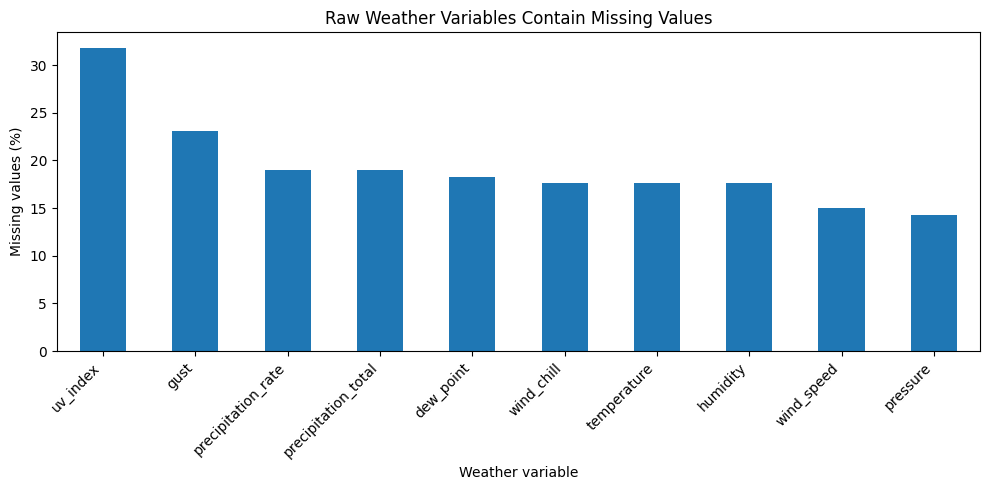

In [3]:
missing_raw = pd.DataFrame({
    "missing_count": raw_df[weather_cols].isna().sum(),
    "missing_percent": raw_df[weather_cols].isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_raw)

plt.figure(figsize=(10, 5))
missing_raw["missing_percent"].plot(kind="bar")
plt.title("Raw Weather Variables Contain Missing Values")
plt.ylabel("Missing values (%)")
plt.xlabel("Weather variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Short Conclusion: Initial Audit

The raw dataset has substantial missing values in several key weather measurements. This means that later analysis should not use the raw file directly without cleaning. The submitted cleaned file has fewer rows and additional time-related columns, suggesting that unusable rows were removed and time features were added.

## 5. Remove Rows With No Weather Measurements

Rows where **all weather measurement columns are missing** cannot support any analysis of weather indicators. These rows are removed before imputation or later analysis.

In [4]:
all_weather_missing = raw_df[weather_cols].isna().all(axis=1)
raw_after_row_filter = raw_df.loc[~all_weather_missing].reset_index(drop=True)
removed_rows = raw_df.loc[all_weather_missing].copy()

row_filter_summary = pd.DataFrame({
    "metric": [
        "Rows in raw data",
        "Rows removed because all weather measurements were missing",
        "Rows after removing unusable records",
        "Rows in submitted cleaned data"
    ],
    "value": [
        len(raw_df),
        int(all_weather_missing.sum()),
        len(raw_after_row_filter),
        len(submitted_cleaned_df)
    ]
})

display(row_filter_summary)

print("Percentage of raw rows removed:", round(all_weather_missing.mean() * 100, 2), "%")

,metric,value
0,Rows in raw data,57475
1,Rows removed because all weather measurements ...,5782
2,Rows after removing unusable records,51693
3,Rows in submitted cleaned data,51693


Percentage of raw rows removed: 10.06 %


In [5]:
# Validate that the row filter matches the submitted cleaned file's identifying columns.
if len(raw_after_row_filter) == len(submitted_cleaned_df):
    key_order_matches = raw_after_row_filter[key_cols].astype(str).equals(
        submitted_cleaned_df[key_cols].astype(str)
    )
else:
    key_order_matches = False

print("Do key columns match after removing all-weather-missing rows?", key_order_matches)

Do key columns match after removing all-weather-missing rows? True


### Short Conclusion: Row Filtering

Rows with no weather measurements were removed because they cannot support weather-indicator analysis. The remaining rows match the submitted cleaned dataset on the identifying columns, so the row-filtering step is consistent with the cleaned file provided by the group member.

## 6. Missing-Value Treatment and Imputation Transparency

The submitted cleaned file contains filled values for remaining missing weather cells. To make this process transparent for the final project, this notebook records **which cells were originally missing** and creates imputation indicator columns.

For the final analysis-ready file, we use a transparent hierarchical median imputation approach:

1. Fill missing values using the median for the same `state`, `city`, `month`, and `hour` where possible.
2. If still missing, use the median for the same `city` and `month`.
3. If still missing, use the median for the same `state` and `month`.
4. If still missing, use the global median for that variable.

This keeps observed raw values unchanged and gives later group members a complete dataset while still preserving imputation flags for careful interpretation.

In [6]:
analysis_ready = raw_after_row_filter.copy()

# Mark which cells were missing before imputation.
for col in weather_cols:
    analysis_ready[f"{col}_was_imputed"] = analysis_ready[col].isna()

imputation_before = pd.DataFrame({
    "missing_after_row_filter": raw_after_row_filter[weather_cols].isna().sum(),
    "missing_percent_after_row_filter": raw_after_row_filter[weather_cols].isna().mean() * 100
}).sort_values("missing_after_row_filter", ascending=False)

display(imputation_before)

,missing_after_row_filter,missing_percent_after_row_filter
uv_index,12516,24.212
gust,7502,14.513
precipitation_rate,5119,9.903
precipitation_total,5119,9.903
dew_point,4728,9.146
wind_chill,4368,8.450
temperature,4330,8.376
humidity,4323,8.363
wind_speed,2860,5.533
pressure,2408,4.658


In [7]:
def hierarchical_median_impute(df: pd.DataFrame, col: str) -> pd.Series:
    filled = df[col].copy()

    grouping_levels = [
        ["state", "city", "month", "hour"],
        ["city", "month"],
        ["state", "month"],
    ]

    for group_cols in grouping_levels:
        group_medians = df.groupby(group_cols)[col].transform("median")
        filled = filled.fillna(group_medians)

    global_median = df[col].median()
    filled = filled.fillna(global_median)

    return filled

for col in weather_cols:
    analysis_ready[col] = hierarchical_median_impute(analysis_ready, col)

imputation_after = pd.DataFrame({
    "missing_after_imputation": analysis_ready[weather_cols].isna().sum()
}).sort_values("missing_after_imputation", ascending=False)

display(imputation_after)

,missing_after_imputation
temperature,0
pressure,0
dew_point,0
humidity,0
wind_speed,0
gust,0
wind_chill,0
uv_index,0
precipitation_rate,0
precipitation_total,0


In [8]:
# Validate that observed raw values were not changed by imputation.
validation_rows = []

for col in weather_cols:
    observed_mask = raw_after_row_filter[col].notna()
    observed_unchanged = np.isclose(
        raw_after_row_filter.loc[observed_mask, col].astype(float),
        analysis_ready.loc[observed_mask, col].astype(float),
        equal_nan=True
    ).all()

    validation_rows.append({
        "column": col,
        "original_observed_values_unchanged": observed_unchanged,
        "imputed_count": int(raw_after_row_filter[col].isna().sum()),
        "imputed_percent": raw_after_row_filter[col].isna().mean() * 100
    })

imputation_validation = pd.DataFrame(validation_rows)
display(imputation_validation)

,column,original_observed_values_unchanged,imputed_count,imputed_percent
0,temperature,True,4330,8.376
1,pressure,True,2408,4.658
2,dew_point,True,4728,9.146
3,humidity,True,4323,8.363
4,wind_speed,True,2860,5.533
5,gust,True,7502,14.513
6,wind_chill,True,4368,8.450
7,uv_index,True,12516,24.212
8,precipitation_rate,True,5119,9.903
9,precipitation_total,True,5119,9.903


### Short Conclusion: Missing-Value Treatment

The final analysis-ready dataset preserves all observed raw weather values and fills remaining missing values using a documented hierarchical median method. Because several variables had substantial missingness before imputation, later analysis should interpret these variables carefully and consider the imputation flags where relevant.

## 7. Time Feature Creation

The raw file stores time across separate columns. This section creates:

- `month_number`: numeric month value
- `datetime`: a single timestamp

In [9]:
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

analysis_ready["month_number"] = analysis_ready["month"].map(month_map)

analysis_ready["datetime"] = pd.to_datetime(
    analysis_ready["year"].astype(str) + "-" +
    analysis_ready["month_number"].astype(str).str.zfill(2) + "-" +
    analysis_ready["day"].astype(str).str.zfill(2) + " " +
    analysis_ready["hour"].astype(str).str.zfill(2) + ":" +
    analysis_ready["minutes"].astype(str).str.zfill(2) + ":" +
    analysis_ready["seconds"].astype(str).str.zfill(2),
    errors="coerce"
)

time_validation = pd.DataFrame({
    "metric": [
        "Missing month_number values",
        "Invalid datetime values",
        "Earliest datetime",
        "Latest datetime"
    ],
    "value": [
        int(analysis_ready["month_number"].isna().sum()),
        int(analysis_ready["datetime"].isna().sum()),
        analysis_ready["datetime"].min(),
        analysis_ready["datetime"].max()
    ]
})

display(time_validation)

,metric,value
0,Missing month_number values,0
1,Invalid datetime values,0
2,Earliest datetime,2018-01-17 01:00:00
3,Latest datetime,2023-08-30 15:59:42


### Short Conclusion: Time Features

The dataset now contains valid `month_number` and `datetime` variables. These features allow later analysis by month, hour, or time order.

## 8. Location Coverage

The dataset does **not** cover all of Malaysia. It contains selected weather records from Kuala Lumpur and Pulau Pinang. This affects how far the project conclusions can be generalised.

,records
state,
Kuala Lumpur,37160
Pulau Pinang,14533


,records
city,
Kuala Lumpur,28201
Sepang,7667
Timur Laut,7611
George Town,2485
Bayan Lepas,1848
Bukit Mertajam,1662
Selayang,1292
Seberang Perai,927


,records
place,
Bukit Bintang,8459
Air Itam,7611
Bukit Jalil,7178
Cheras,3902
Ampang Jaya,3881
Bandar Sri Permaisuri,3821
Jalan Ayer Hitam,2918
Kampung Dato' Abu Bakar Baginda,2851
Sepang,1898


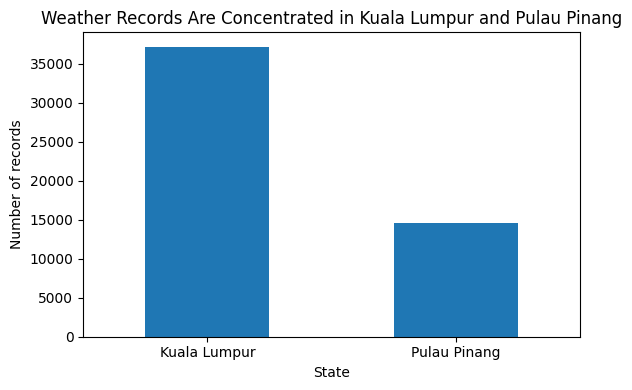

In [10]:
state_counts = analysis_ready["state"].value_counts()
city_counts = analysis_ready["city"].value_counts()
place_counts = analysis_ready["place"].value_counts()

display(pd.DataFrame({"records": state_counts}))
display(pd.DataFrame({"records": city_counts}))
display(pd.DataFrame({"records": place_counts.head(15)}))

plt.figure(figsize=(6, 4))
state_counts.plot(kind="bar")
plt.title("Weather Records Are Concentrated in Kuala Lumpur and Pulau Pinang")
plt.ylabel("Number of records")
plt.xlabel("State")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

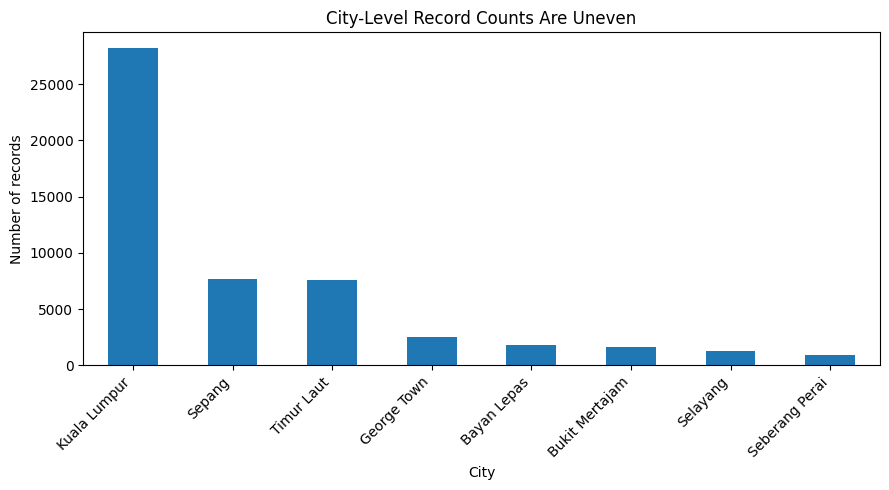

In [11]:
plt.figure(figsize=(9, 5))
city_counts.plot(kind="bar")
plt.title("City-Level Record Counts Are Uneven")
plt.ylabel("Number of records")
plt.xlabel("City")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Short Conclusion: Location Coverage

The dataset mainly represents selected locations in Kuala Lumpur and Pulau Pinang. It should not be described as complete national coverage of Malaysia. Later conclusions should be framed as insights from selected Malaysian weather records.

## 9. Unusual Values and Outlier Checks

Unusual values were checked before later analysis because they can affect visualisations, correlations and recommendations. These values were not automatically removed because some may represent rare but real weather events.

In [12]:
numeric_summary = analysis_ready[weather_cols].describe().T
display(numeric_summary)

unusual_summary = pd.DataFrame({
    "check": [
        "humidity equal to 0",
        "uv_index greater than 11",
        "precipitation_rate greater than 100",
        "precipitation_total greater than 100",
        "gust greater than 30",
        "wind_speed greater than 20"
    ],
    "count": [
        int((analysis_ready["humidity"] == 0).sum()),
        int((analysis_ready["uv_index"] > 11).sum()),
        int((analysis_ready["precipitation_rate"] > 100).sum()),
        int((analysis_ready["precipitation_total"] > 100).sum()),
        int((analysis_ready["gust"] > 30).sum()),
        int((analysis_ready["wind_speed"] > 20).sum())
    ]
})

display(unusual_summary)

,count,mean,std,min,25%,50%,75%,max
temperature,"51,693.000",28.014,3.099,17.800,25.600,27.300,30.300,41.000
pressure,"51,693.000","1,010.199",4.273,996.950,"1,007.450","1,010.500","1,013.240","1,023.230"
dew_point,"51,693.000",24.300,1.848,7.700,23.400,24.200,25.000,32.200
humidity,"51,693.000",82.022,13.402,0.000,72.800,84.400,93.000,100.000
wind_speed,"51,693.000",2.349,3.444,0.000,0.000,1.000,3.300,33.800
gust,"51,693.000",4.053,7.642,0.000,0.000,1.800,4.400,59.000
wind_chill,"51,693.000",28.012,3.096,17.800,25.600,27.300,30.300,41.000
uv_index,"51,693.000",1.319,2.457,0.000,0.000,0.000,2.000,16.000
precipitation_rate,"51,693.000",0.309,3.791,0.000,0.000,0.000,0.000,432.590
precipitation_total,"51,693.000",2.815,10.342,0.000,0.000,0.000,0.200,162.810


,check,count
0,humidity equal to 0,27
1,uv_index greater than 11,235
2,precipitation_rate greater than 100,9
3,precipitation_total greater than 100,102
4,gust greater than 30,1364
5,wind_speed greater than 20,116


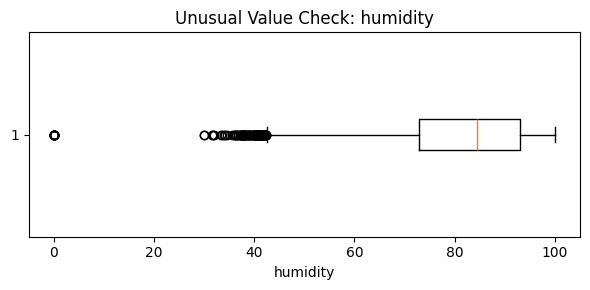

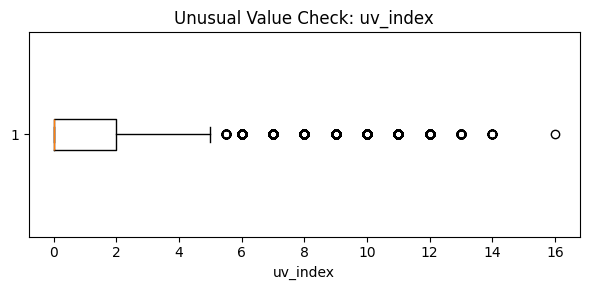

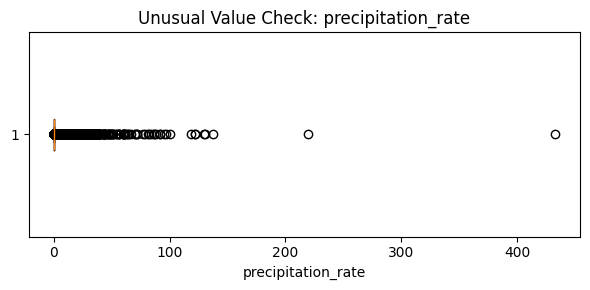

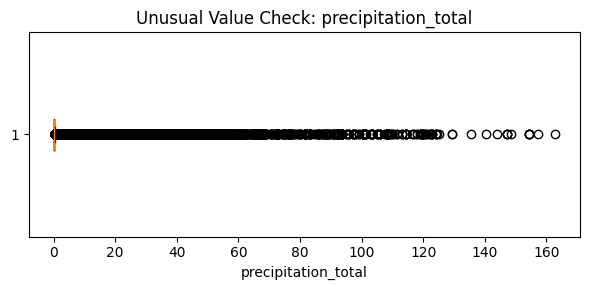

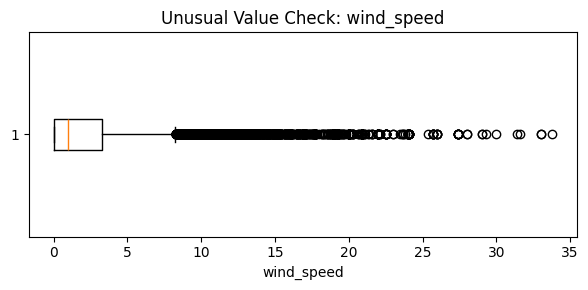

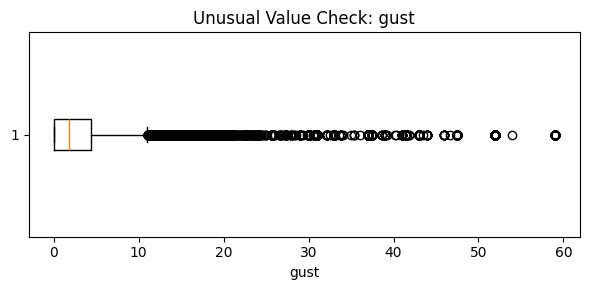

In [13]:
# Boxplots for selected variables to visually inspect unusual values.
selected_outlier_cols = ["humidity", "uv_index", "precipitation_rate", "precipitation_total", "wind_speed", "gust"]

for col in selected_outlier_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(analysis_ready[col].dropna(), vert=False)
    plt.title(f"Unusual Value Check: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Short Conclusion: Unusual Values

Some variables contain unusual values, including humidity equal to 0, UV index above the standard 11+ extreme range, and very high precipitation or wind values. These values are retained because they may represent extreme weather conditions, but later analysis should interpret them carefully.

## 10. Feature Preparation for Later Members

This section creates the core derived variables that Member 3 and Member 4 can use for comfort and warning-indicator analysis.

In [14]:
# Comfort-related features
analysis_ready["temperature_difference"] = analysis_ready["temperature"] - analysis_ready["wind_chill"]

# Wind-risk feature
analysis_ready["gust_difference"] = analysis_ready["gust"] - analysis_ready["wind_speed"]

# Rainfall indicator
analysis_ready["rain_event"] = analysis_ready["precipitation_total"] > 0

# Pressure trend by place and datetime
analysis_ready = analysis_ready.sort_values(["place", "datetime"]).reset_index(drop=True)
analysis_ready["pressure_change"] = analysis_ready.groupby("place")["pressure"].diff()
analysis_ready["falling_pressure"] = analysis_ready["pressure_change"] < 0

# UV categories
def classify_uv(value):
    if pd.isna(value):
        return np.nan
    if value <= 2:
        return "Low"
    elif value <= 5:
        return "Moderate"
    elif value <= 7:
        return "High"
    elif value <= 10:
        return "Very High"
    else:
        return "Extreme"

analysis_ready["uv_category"] = analysis_ready["uv_index"].apply(classify_uv)
analysis_ready["high_uv"] = analysis_ready["uv_index"] >= 6

feature_summary = pd.DataFrame({
    "feature": [
        "temperature_difference",
        "gust_difference",
        "rain_event",
        "pressure_change",
        "falling_pressure",
        "uv_category",
        "high_uv"
    ],
    "purpose": [
        "Check whether wind chill adds information beyond temperature",
        "Check whether gust adds sudden wind-risk information beyond wind speed",
        "Convert precipitation total into a simple rainfall indicator",
        "Measure change in pressure by place over time",
        "Identify whether pressure is falling",
        "Group UV index into public warning categories",
        "Flag UV records at high or higher risk"
    ]
})

display(feature_summary)
display(analysis_ready[["temperature_difference", "gust_difference", "rain_event", "pressure_change", "falling_pressure", "uv_category", "high_uv"]].head())

,feature,purpose
0,temperature_difference,Check whether wind chill adds information beyo...
1,gust_difference,Check whether gust adds sudden wind-risk infor...
2,rain_event,Convert precipitation total into a simple rain...
3,pressure_change,Measure change in pressure by place over time
4,falling_pressure,Identify whether pressure is falling
5,uv_category,Group UV index into public warning categories
6,high_uv,Flag UV records at high or higher risk


,temperature_difference,gust_difference,rain_event,pressure_change,falling_pressure,uv_category,high_uv
0,0.000,0.000,True,NaN,False,Low,False
1,0.000,0.000,True,0.680,False,Low,False
2,0.000,0.000,True,0.500,False,Low,False
3,0.000,0.000,True,0.340,False,Low,False
4,0.000,0.000,False,0.850,False,Low,False


### Short Conclusion: Feature Preparation

The final analysis-ready dataset now includes derived variables that directly support the group research questions. These features help the project move beyond simple description into indicator comparison and public communication recommendations.

## 11. Final Validation and Export

This section confirms that the final analysis-ready dataset is suitable for later analysis and exports it as a clean CSV file.

In [15]:
final_validation = pd.DataFrame({
    "metric": [
        "Final rows",
        "Final columns",
        "Duplicate rows",
        "Missing values in main weather columns",
        "Invalid datetime values",
        "Weather imputation flag columns",
        "Derived analysis features"
    ],
    "value": [
        len(analysis_ready),
        analysis_ready.shape[1],
        int(analysis_ready.duplicated().sum()),
        int(analysis_ready[weather_cols].isna().sum().sum()),
        int(analysis_ready["datetime"].isna().sum()),
        len([c for c in analysis_ready.columns if c.endswith("_was_imputed")]),
        ", ".join([
            "temperature_difference", "gust_difference", "rain_event",
            "pressure_change", "falling_pressure", "uv_category", "high_uv"
        ])
    ]
})

display(final_validation)

analysis_ready.to_csv(FINAL_CLEANED_PATH, index=False)
print(f"Final analysis-ready dataset exported to: {FINAL_CLEANED_PATH}")

,metric,value
0,Final rows,51693
1,Final columns,38
2,Duplicate rows,0
3,Missing values in main weather columns,0
4,Invalid datetime values,0
5,Weather imputation flag columns,10
6,Derived analysis features,"temperature_difference, gust_difference, rain_..."


Final analysis-ready dataset exported to: /mnt/data/ADS1001_member2_cleaning_final_package/data/malaysia_weather_cleaned_final.csv


### Note on `pressure_change` Missing Values

Although the main weather measurement columns contain no missing values in the final cleaned dataset, `pressure_change` may contain missing values for the first record of each place. This is expected because pressure change requires a previous pressure observation for comparison. These missing values are not treated as data cleaning errors.

## 12. Data Cleaning Summary for Presentation

The raw dataset contained 57,475 rows and 19 columns. Rows with no usable weather measurements were removed, leaving an analysis-ready dataset with 51,693 rows. Missing weather values were handled using a transparent hierarchical median imputation method, and imputation flags were created so that later analysis can identify which cells were originally missing.

The final dataset includes valid datetime fields, location information, key weather measurements and derived analysis features. However, the dataset only covers selected locations in Kuala Lumpur and Pulau Pinang, so findings should not be generalised to all of Malaysia. The data dictionary also mentions air quality, but no air quality variables are available in the CSV.

## 13. Handoff Notes for Other Members

### For Member 3: Outdoor comfort analysis
Use:
- `temperature`
- `wind_chill`
- `temperature_difference`
- `humidity`
- `dew_point`

Recommended analysis:
- Temperature vs wind chill scatter plot
- Distribution of `temperature_difference`
- Humidity vs dew point scatter plot
- Short conclusion about public comfort communication

### For Member 4: Public risk and warning analysis
Use:
- `pressure`
- `precipitation_total`
- `rain_event`
- `pressure_change`
- `wind_speed`
- `gust`
- `gust_difference`
- `uv_index`
- `uv_category`
- `high_uv`

Recommended analysis:
- Pressure / rainfall relationship
- Wind speed vs gust relationship
- UV category distribution
- UV by hour or month
- Short conclusion about public warnings

### For Member 5: Summary
Use:
- location limitation
- missing/imputation summary
- unusual values summary
- final feature list
- air quality mismatch limitation

## 14. Final Short Conclusion

Member 2's data preparation is complete. The dataset is now ready for Member 3 and Member 4 to conduct focused analyses on comfort and warning indicators. The final cleaned file uses relative paths, contains documented cleaning decisions, includes imputation flags, checks location coverage and unusual values, and creates the derived variables needed for the later research questions.

## Member 2 Completion Check

This completed version includes the final group member name and clarifies that `pressure_change` missing values are expected for first records within each location. The notebook remains suitable for the group final notebook because it documents data loading, data dictionary alignment, missing-value handling, imputation flags, datetime validation, location coverage, unusual-value checks, feature engineering, final validation and handoff notes.